### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 2
### Due: Monday, Sep. 21 at 11.59pm CST
---

## Problem 1

This question is about Monte Carlo integration. A standard Gaussian integral takes the form 

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

1) Write down the usual form of a Gaussian distribution with $\mu=0$ and $\sigma=\sigma$ that is normalized between $\infty$ and $+\infty$. What is the corresponding form of a half-Gaussian distribution between $0$ and $+\infty$? (Remember that the half-Gaussian distribution must be normalized such that it integrates to one.)

2) Manipulate the above equation such that you can write the left hand side in terms of a normalized half-Gaussian distribution. 

3) Draw $N=10^5$ samples from a $\sigma=3$ normal distribution, mask the samples such that only positive values are accepted, then perform Monte Carlo integration using your equation in (2). Confirm that this *approximately* matches the value computed from the right hand side of the equation. If you don't get approximately matching values then you may have forgotten normalization factors for the Gaussian, or constant factors from translating a normalized Gaussian to a half-Gaussian.

4) Repeat (3) for $N=[10^2,10^3,10^4]$, computing the integral using $100$ different batches of random samples for each $N$. Record all calculated values at all $N$. 

5) Make a plot that shows $\log_{10}N$ along the $x$-axis and the spread between the maximum and minimum Monte Carlo integral values that you get at each $N$ on the $y$-axis. (Note: matplotlib's `fill_between` command is useful for this). Plot a horizontal line on the same figure to show the precise mathematical value. You should see that Monte Carlo integration results in less numerical spread as $N$ gets larger.

### Solution

$\textbf{{\color{blue}1.1}}$ 

The general form of Gaussian probability is $$p(x)=\frac{1}{\sigma \sqrt{2 \pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$ Here $\mu=0$ and $\sigma=\sigma$, so $$p(x)=\frac{1}{\sigma \sqrt{2 \pi}}\exp\left[-\frac{x^2}{2\sigma^2}\right],$$ where it should satisfy $$\int_{-\infty}^{+\infty}p(x)dx=1.$$ But from the previous relation should also satisfy the condition above. They are now asking for the corresponding form of a half Gaussian distribution from $0$ to $\infty$. Since a Gaussian is centered at zero or the distribution is symmetric, so $$\int_{0}^{+\infty}p(x)dx=\frac{1}{2},$$ and our previous Gaussian can be expressed as the following $$p_{half,G}(x)=\frac{\sqrt{2}}{\sigma \sqrt{\pi}}\exp\left[-\frac{x^2}{2\sigma^2}\right],$$ so that $$\int_{0}^{+\infty}p_{half,G}(x)dx=1.$$

$\textbf{{\color{blue}1.2}}$ 

From $$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4$$ and $$p_{half,G}(x)=\frac{\sqrt{2}}{\sigma \sqrt{\pi}}\exp\left[-\frac{x^2}{2\sigma^2}\right],$$ we get $$\exp\left[-\frac{x^2}{2\sigma^2}\right]=\frac{\sigma \sqrt{\pi}}{\sqrt{2}}p_{half,G}(x).$$ So $$ \frac{\sigma \sqrt{\pi}}{\sqrt{2}}\int_0^\infty x^3 p_{half,G}(x) \,dx = 2\sigma^4$$

$\textbf{{\color{blue}1.3}}$

In [7]:
import numpy as np

sigma = 3
N = 10**5

samples = np.random.normal(0, sigma, N)
sample_positive = samples[samples > 0]

value_approx = (sigma*np.sqrt(np.pi)/np.sqrt(2))*np.mean((sample_positive)**3)
value_rightside = 2*sigma**4

print("Monte Carlo aprroximation=", value_approx)
print("Exact value=", value_rightside)

Monte Carlo aprroximation= 160.10333315541035
Exact value= 162


$\textbf{{\color{blue}1.4}}$

In [11]:
N_values = [10**2, 10**3, 10**4]

results = {}

for N in N_values:
    values = []

    for i in range(100):
        samples = np.random.normal(0, sigma, N)
        sample_positive = samples[samples > 0]

        value_approx = (sigma*np.sqrt(np.pi)/np.sqrt(2))*np.mean(sample_positive**3)

        values.append(value_approx)

    results[N] = np.array(values)
        

$\textbf{{\color{blue}1.5}}$

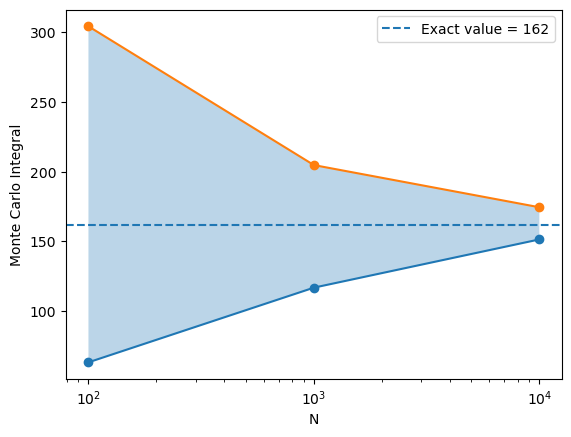

In [15]:
import matplotlib.pyplot as plt

minimums = []
maximums = []

for N in N_values:
    minimums.append(np.min(results[N]))
    maximums.append(np.max(results[N]))

plt.plot(N_values, minimums, marker = 'o')
plt.plot(N_values, maximums, marker = 'o')
plt.fill_between(N_values, minimums, maximums, alpha=0.3)

plt.axhline(value_rightside, linestyle='--', label = 'Exact value = 162')

plt.xscale('log')

plt.xlabel('N')
plt.ylabel('Monte Carlo Integral')
plt.legend()

plt.show()

## Problem 2

This question is about IQ. It's a flawed and questionable metric, but useful for this problem. By definition, IQ is calibrated as a Gaussian distribution with $\mu=100$ and $\sigma=15$. 

1) Create a `scipy.stats` Gaussian object with these properties. Plot the distribution, and print out 10 random draws, along with the pdf at $x=145$. 

2) Access the `cdf` property of the Gaussian object and plot it over the same $x$-range as in (1) but in a different figure. Access the `ppf` property (percent point function) and use *inverse transform sampling* of the cdf to draw $10^4$ random samples, and make a histogram of these. Overplot the pdf from (1). These should match.

3) What fraction of people have IQ > 145? *Hint: investigate all the properties of the Gaussian object from (1) to find the relevant property that gives you this, or perform a calculation involving the cdf.*

4) What IQ corresponds to "one in a million"?

### Solution

$\textbf{{\color{blue}2.1}}$

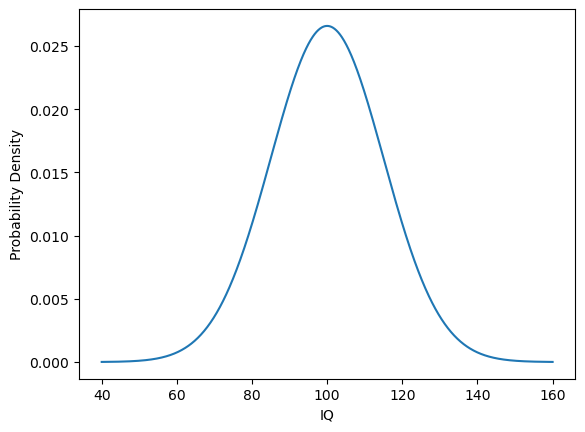

10 random draws: [107.38107118  99.97580848  92.20015266  94.70124059  92.48040535
  91.10827463  94.13043122  95.56150081 100.88137687  92.44346965]
PDF at x = 145: 0.0002954565607958672


In [16]:
from scipy.stats import norm

mu = 100
sigma = 15

IQ = norm(loc = mu, scale = sigma)

x = np.linspace(40, 160, 1000)

plt.plot(x, IQ.pdf(x))
plt.xlabel('IQ')
plt.ylabel('Probability Density')
plt.show()

random_IQ = IQ.rvs(size=10)
print("10 random draws:", random_IQ)

pdf_145 = IQ.pdf(145)
print("PDF at x = 145:", pdf_145)

$\textbf{{\color{blue}2.2}}$

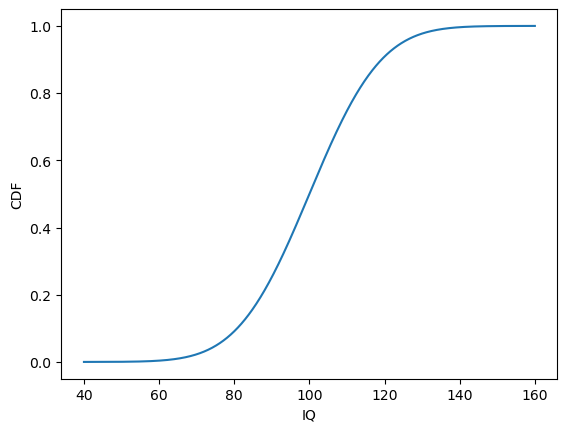

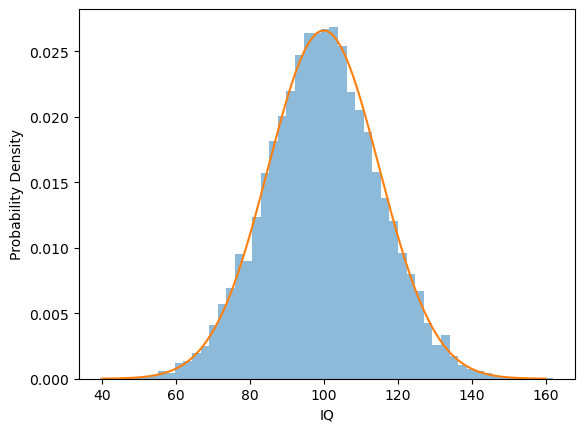

In [19]:
plt.plot(x, IQ.cdf(x))

plt.xlabel('IQ')
plt.ylabel('CDF')

plt.show()

u = np.random.uniform(0, 1, 10**4)
sample_ppf = IQ.ppf(u)

plt.hist(sample_ppf, bins=50, density=True, alpha=0.5)

plt.plot(x, IQ.pdf(x))

plt.xlabel('IQ')
plt.ylabel('Probability Density')

plt.show()

$\textbf{{\color{blue}2.3}}$

We know CDF gives the probability below a value or $CDF(145)= P(X\leq 145)$, therefore, $P(X> 145)=1-CDF(145)$

In [21]:
frac  = 1 - IQ.cdf(145)

print("Frcation of people with IQ more than 145:", frac)

Frcation of people with IQ more than 145: 0.0013498980316301035


$\textbf{{\color{blue}2.4}}$

One in a million is $10^{-6}.$ So, we want an IQ which gives the probability $10^{-6}$, for which we are going to use PPF. 

In [24]:
IQ_one_in_million = IQ.ppf(1-1e-6)

print ("IQ correspond to one in a million is", IQ_one_in_million)

IQ correspond to one in a million is 171.3013646322563


## Problem 3

This question is about Poisson distributions. A famous early application was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898. Let's take a short look at the kind of data he analyzed.

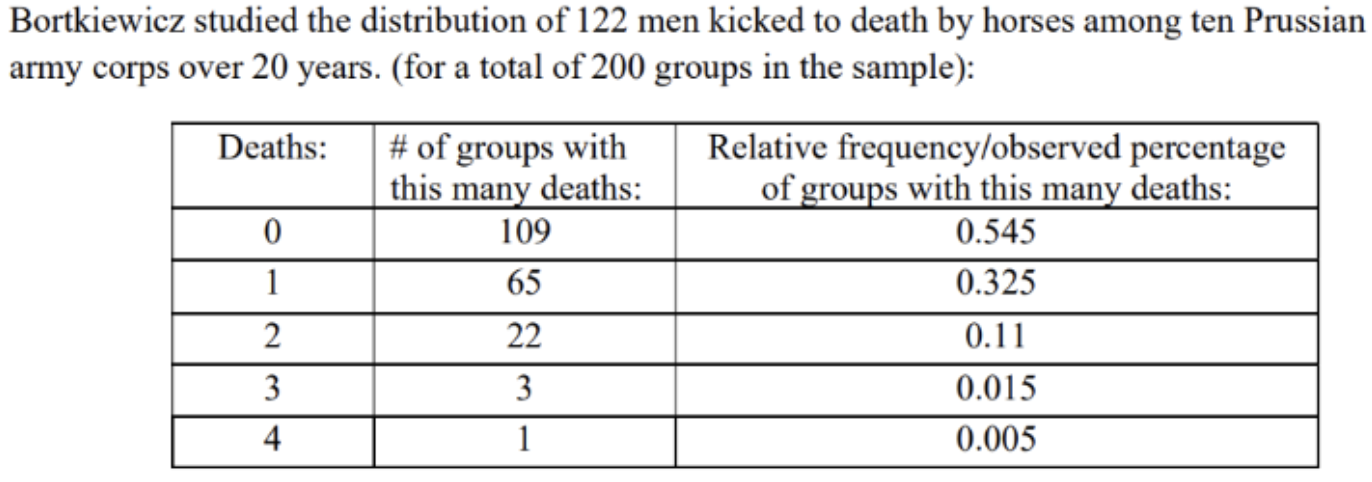

The data essentially consist of 200 total years of Prussian army corps information (i.e. ten army corps over 20 years).

1) Make a plot of the first and third columns of this data.

2) Plot a few Poisson distributions on top that are characterized by different $\mu$ values that might be reasonable guesses for how the data is distributed.

3) We'll come to model fitting next week, but for now use the descriptive sample statistics that you can calculate from this data to deduce the $\mu$ of the modeled Poisson distribution, e.g. the mean, std, median, mode, skewness, and kurtosis, where relevant. Do this however you like, but note that with the data in the table you won't just be able to get a sample mean, since these are tabulated densities, not samples. 

*Hint: use a weighted mean, or alternatively make a dataset that has the numbers 0,1,2,3,4 in agreement with their frequency in the table.*

4) Plot the Poisson distribution with the $\mu$ found in (3) alongside the data.

### Solution

$\textbf{{\color{blue}3.1}}$

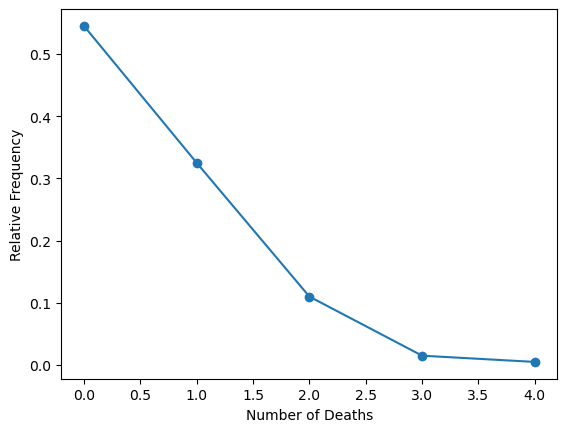

In [25]:
deaths = np.array([0,1,2,3,4])
relative_frequency = np.array([0.545,0.325,0.11,0.015,0.005])

plt.plot(deaths, relative_frequency, marker = 'o')
plt.xlabel('Number of Deaths')
plt.ylabel('Relative Frequency')

plt.show()

$\textbf{{\color{blue}3.2}}$

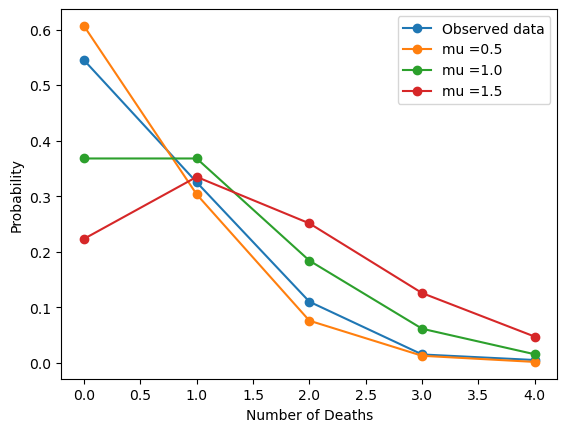

In [31]:
from scipy.stats import poisson

mu_val = [0.5, 1.0, 1.5]

plt.plot(deaths, relative_frequency, marker = 'o', label = 'Observed data')

for mu in mu_val:
    plt.plot(deaths, poisson.pmf(deaths, mu), marker='o', label=f'mu ={mu}')

plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.legend()

plt.show()

$\textbf{{\color{blue}3.3}}$

In [34]:
from scipy.stats import skew, kurtosis

group = np.array([109,65,22,3,1])

data = np.repeat(deaths, group)

mean = np.mean(data)
std = np.std(data)
median = np.median(data)
mode = deaths[np.argmax(group)]
skewness = skew(data)
kurt = kurtosis(data)

print("Mean =", mean)
print("Standard deviation =", std)
print("Median =", median)
print("Mode =", mode)
print("Skewness =", skewness)
print("Kurtosis =", kurt)

Mean = 0.61
Standard deviation = 0.7796794213008319
Median = 0.0
Mode = 0
Skewness = 1.245997823097657
Kurtosis = 1.4470478232796058


$\textbf{{\color{blue}3.4}}$

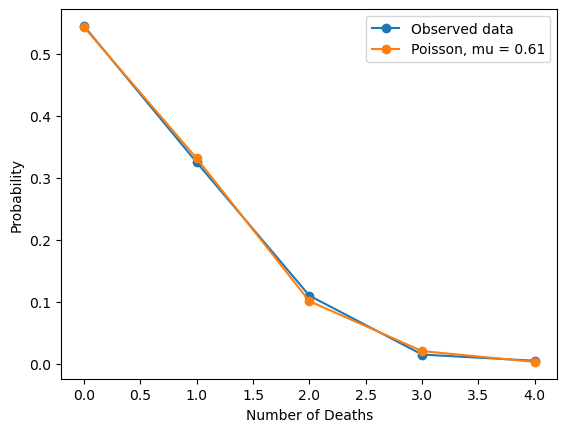

In [35]:
mu = mean

poisson_fit = poisson.pmf(deaths, mu)

plt.plot(deaths, relative_frequency, marker = 'o', label = 'Observed data')
plt.plot(deaths, poisson_fit, marker = 'o', label = f'Poisson, mu = {mu}')

plt.xlabel('Number of Deaths')
plt.ylabel('Probability')
plt.legend()

plt.show()